In [1]:
import sys
print(sys.executable)

c:\Users\Asus\Desktop\ride-hailing-ml\venv\Scripts\python.exe


In [3]:
import sys
from pathlib import Path

# Project root = one level above the notebooks folder
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\Asus\Desktop\ride-hailing-ml


# Exploratory Data Analysis — NYC Taxi Trip Duration

Goal: understand the shape of the raw data and quantify the specific
data-quality issues that `src/data/clean_data.py` (Phase 4) will need
to handle. This notebook doesn't clean anything — it only measures.

In [4]:
import logging

import matplotlib.pyplot as plt

from src.data.load_data import load_raw_data
from src.utils.config_loader import load_config
from src.visualization import plots

logging.basicConfig(level=logging.INFO)

config = load_config()
df = load_raw_data()
df.shape

INFO:src.utils.config_loader:Loaded configuration from C:\Users\Asus\Desktop\ride-hailing-ml\config\config.yaml
INFO:src.data.load_data:Loading raw dataset from C:\Users\Asus\Desktop\ride-hailing-ml\data\raw\train.csv
INFO:src.data.load_data:Loaded 1,458,644 rows, 11 columns (115.5 MB in memory)


(1458644, 11)

## 1. Target distribution: `trip_duration`

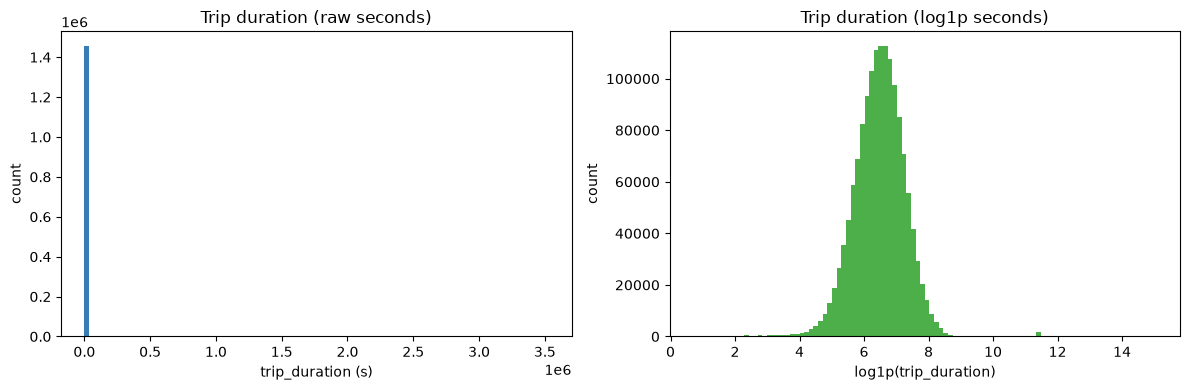

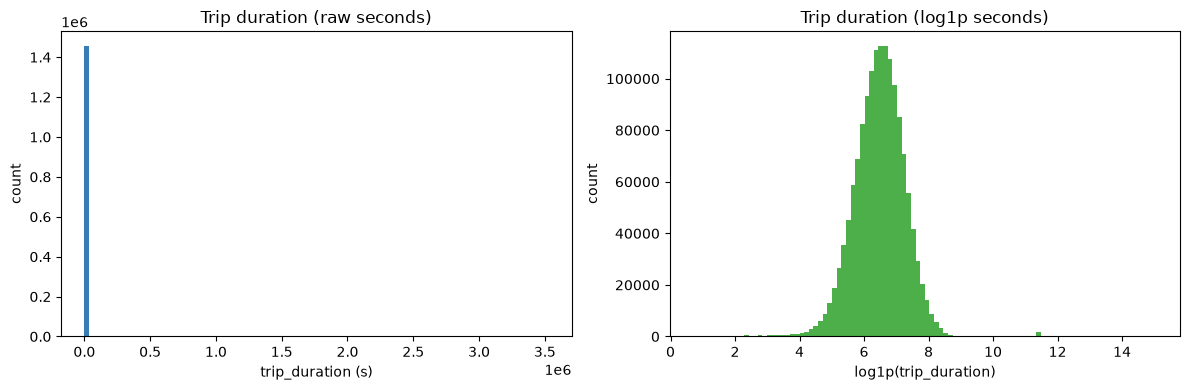

In [6]:
plots.plot_trip_duration_distribution(df)

**Finding:** raw `trip_duration` is severely right-skewed, as expected
for a duration variable — most trips cluster under ~20 minutes, with a
long tail. The `log1p` panel is close to bell-shaped, which is why
Phase 8 will train duration models against a log-transformed target
rather than raw seconds.

## 2. Quantifying duration outliers

`config.yaml` already defines `min_trip_duration_seconds: 10` and
`max_trip_duration_seconds: 86400`. Before Phase 4 applies these as
cleaning rules, let's see exactly how many rows they affect.

In [7]:
min_s = config["data"]["min_trip_duration_seconds"]
max_s = config["data"]["max_trip_duration_seconds"]

too_short = (df["trip_duration"] < min_s).sum()
too_long = (df["trip_duration"] > max_s).sum()

print(f"Trips under {min_s}s:  {too_short:,} ({too_short / len(df):.4%})")
print(f"Trips over {max_s}s:   {too_long:,} ({too_long / len(df):.4%})")

Trips under 10s:  1,984 (0.1360%)
Trips over 86400s:   4 (0.0003%)


**Finding:** both categories should be a small fraction of a percent
of the dataset — consistent with data-entry/GPS errors rather than a
meaningful subpopulation. This is the evidence Phase 4 needs to drop
these rows with confidence rather than guessing at a threshold.

## 3. Pickup geography

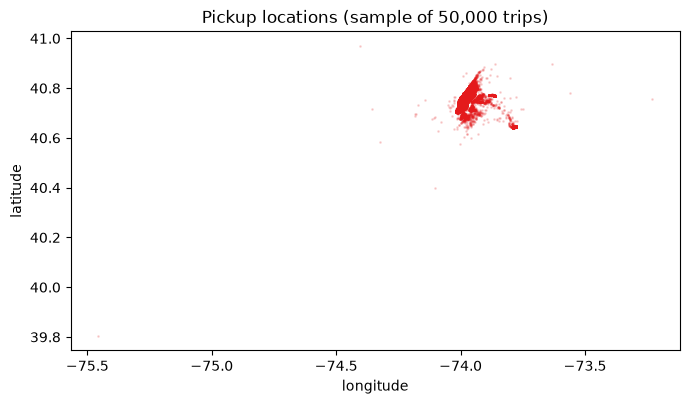

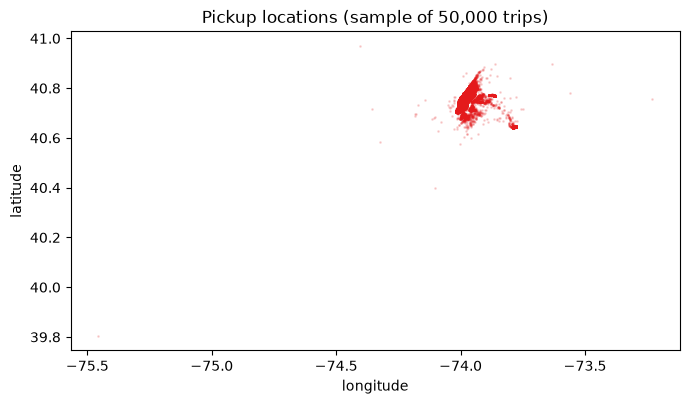

In [8]:
plots.plot_pickup_hotspots(df)

**Finding:** pickups concentrate heavily over Manhattan, with visibly
tighter secondary clusters further out — these correspond to airport
terminals (JFK, LaGuardia). This uneven density is exactly why Phase 6
uses K-Means rather than an equal-area grid for pickup zones: a grid
would waste zones on empty water and outer boroughs while
under-resolving the dense Manhattan core where most of the actual
demand-forecasting signal lives.

## 4. Quantifying geographic outliers

Same approach as duration: `config.yaml` already defines NYC bounding
box limits. How many rows actually fall outside them?

In [9]:
lat_lo, lat_hi = config["data"]["nyc_lat_bounds"]
lon_lo, lon_hi = config["data"]["nyc_lon_bounds"]

bad_pickup = (
    ~df["pickup_latitude"].between(lat_lo, lat_hi)
    | ~df["pickup_longitude"].between(lon_lo, lon_hi)
)
bad_dropoff = (
    ~df["dropoff_latitude"].between(lat_lo, lat_hi)
    | ~df["dropoff_longitude"].between(lon_lo, lon_hi)
)

print(f"Pickup coords outside NYC bounds:  {bad_pickup.sum():,} ({bad_pickup.mean():.4%})")
print(f"Dropoff coords outside NYC bounds: {bad_dropoff.sum():,} ({bad_dropoff.mean():.4%})")

Pickup coords outside NYC bounds:  196 (0.0134%)
Dropoff coords outside NYC bounds: 609 (0.0418%)


**Finding:** a small number of rows have coordinates nowhere near New
York — these are GPS errors, not unusual trips, and Phase 4 will drop
them before any distance/bearing feature is computed on top of them.

## 5. Temporal pattern: pickups by hour

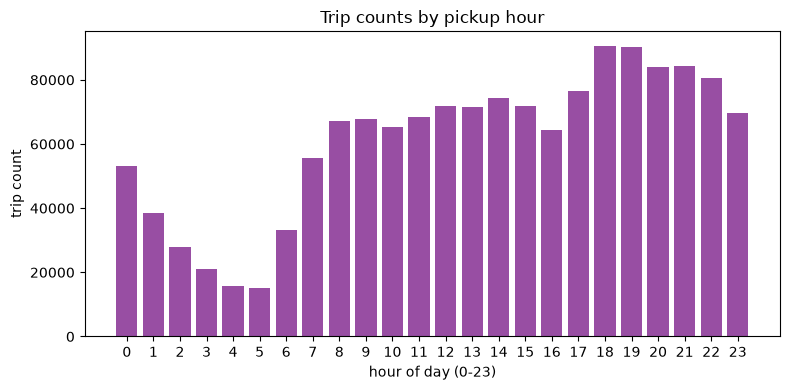

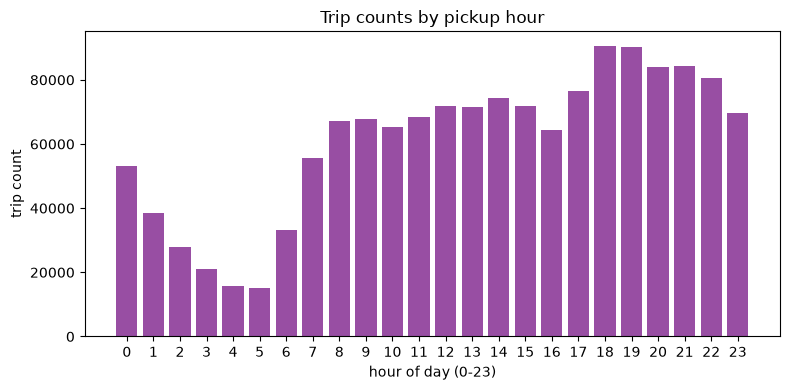

In [10]:
plots.plot_trips_by_hour(df)

**Finding:** volume dips overnight and peaks around evening rush, with
a smaller morning peak. Hour alone, fed to a model as a plain integer,
would tell it hour 23 and hour 0 are as different as possible — when
they're one hour apart. This is the direct justification for the
cyclic sine/cosine hour encoding built in Phase 5.

## 6. One-off checks: passenger count and vendor

These charts are single-use — nothing in a later phase re-plots them,
so they stay here as inline matplotlib rather than joining the shared
`plots.py` library. That's the same "don't duplicate logic, but don't
over-engineer a one-time look either" judgment call from Phase 3's
first file, applied in the other direction.

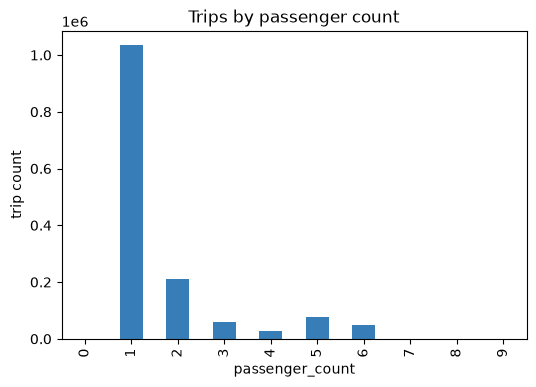

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
df["passenger_count"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#377EB8")
ax.set_title("Trips by passenger count")
ax.set_xlabel("passenger_count")
ax.set_ylabel("trip count")
plt.show()

**Finding:** the overwhelming majority of trips carry 1 passenger, as
expected for a taxi dataset. Watch for a `0` bar — a trip with zero
passengers is a data error, and if present in meaningful volume it's
another row worth flagging in Phase 4.

In [12]:
df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

## 7. Missing values

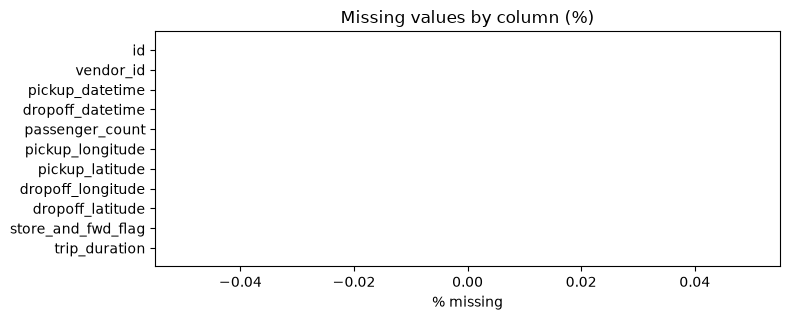

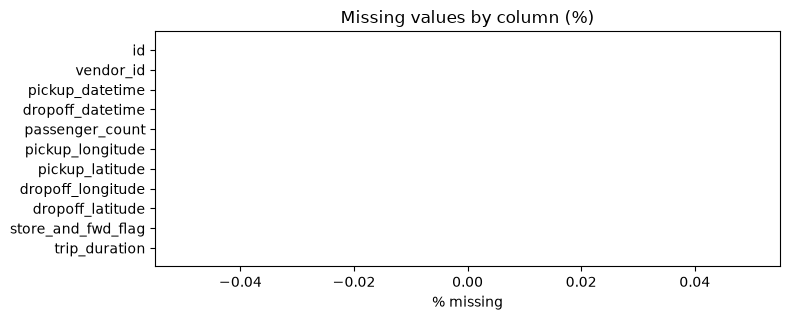

In [13]:
plots.plot_missing_value_summary(df)

**Finding:** this dataset is typically clean on missingness. If your
run shows otherwise, treat that as a real finding to carry into
Phase 4 — don't assume the "usually clean" pattern holds without
checking your own copy of the file.

## 8. Correlation heatmap (numeric columns, pre-feature-engineering)

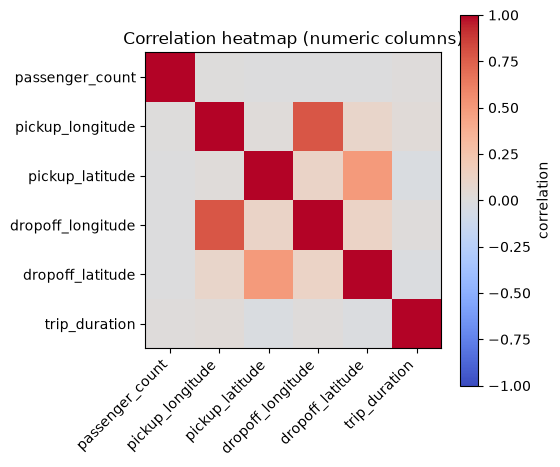

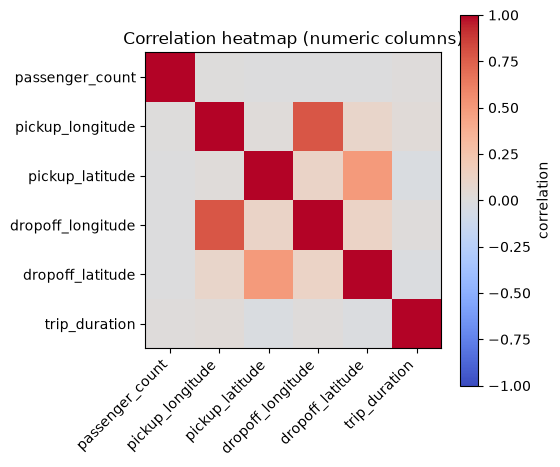

In [14]:
plots.plot_correlation_heatmap(df)

**Finding:** raw `pickup_longitude`/`pickup_latitude` correlate weakly
with `trip_duration` on their own — a straight-line distance derived
from *both* pickup and dropoff coordinates together should carry far
more signal than either coordinate in isolation. This is the case for
building the haversine distance feature in Phase 5, evidenced rather
than assumed.

## Summary — inputs to Phase 4

| Issue | Evidence | Phase 4 action |
|---|---|---|
| `trip_duration` outliers | counted above against config bounds | drop rows outside `[min_trip_duration_seconds, max_trip_duration_seconds]` |
| Out-of-bounds coordinates | counted above against config bounds | drop rows outside `nyc_lat_bounds` / `nyc_lon_bounds` |
| `passenger_count == 0` | visible in bar chart, exact count TBD in Phase 4 | flag or drop, decision made explicitly in `clean_data.py` |
| Missing values | near-zero, confirmed above | no imputation strategy needed unless your own run shows otherwise |

Nothing here has been dropped or modified — this notebook only
measures. Phase 4 turns these findings into an explicit, testable
`clean_data.py`.